
## K Means Clustering with Python


## Method Used

K Means Clustering is an unsupervised learning algorithm that tries to cluster data based on their similarity. Unsupervised learning means that there is no outcome to be predicted, and the algorithm just tries to find patterns in the data. In k means clustering, we have the specify the number of clusters we want the data to be grouped into. The algorithm randomly assigns each observation to a cluster, and finds the centroid of each cluster. Then, the algorithm iterates through two steps:

Reassign data points to the cluster whose centroid is closest. Calculate new centroid of each cluster. These two steps are repeated till the within cluster variation cannot be reduced any further. The within cluster variation is calculated as the sum of the euclidean distance between the data points and their respective cluster centroids.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data_iris = pd.read_csv('iris.csv')

In [3]:
data_iris.head(60)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [4]:
data_iris.tail(60)

,sepal_length,sepal_width,petal_length,petal_width,species
90,5.5,2.6,4.4,1.2,Iris-versicolor
91,6.1,3.0,4.6,1.4,Iris-versicolor
92,5.8,2.6,4.0,1.2,Iris-versicolor
93,5.0,2.3,3.3,1.0,Iris-versicolor
94,5.6,2.7,4.2,1.3,Iris-versicolor
95,5.7,3.0,4.2,1.2,Iris-versicolor
96,5.7,2.9,4.2,1.3,Iris-versicolor
97,6.2,2.9,4.3,1.3,Iris-versicolor
98,5.1,2.5,3.0,1.1,Iris-versicolor
99,5.7,2.8,4.1,1.3,Iris-versicolor


In [5]:
data_iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [16]:
data_iris['species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [17]:
data_iris['species'].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

<Axes: >

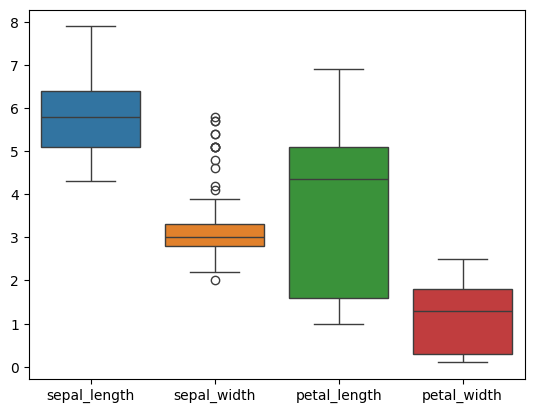

In [18]:
sns.boxplot(data_iris.iloc[:,0:5])

In [19]:
# Making Dataset for Clustering

In [20]:
iris = data_iris.iloc[:,0:4] # removing the final lable or result lable
iris

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


# importing the K-Means

In [21]:
from sklearn.cluster import KMeans

# fit the data in algo

In [28]:
iris_cluster = KMeans(n_clusters=10)

In [29]:
iris_cluster.fit(iris)

KMeans(n_clusters=10)

In [30]:
iris_cluster.labels_

array([9, 1, 1, 1, 9, 9, 1, 9, 1, 1, 9, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 1, 9, 9, 9, 1, 1, 9, 9, 9, 1, 1, 9, 1, 1, 9, 9, 1, 1, 9,
       9, 1, 9, 1, 9, 1, 6, 6, 6, 5, 6, 5, 6, 8, 6, 5, 8, 5, 0, 7, 5, 6,
       5, 5, 0, 5, 7, 5, 7, 7, 6, 6, 6, 6, 7, 5, 5, 5, 5, 7, 5, 7, 6, 0,
       5, 5, 5, 7, 5, 8, 5, 5, 5, 6, 8, 5, 2, 7, 4, 2, 2, 4, 5, 4, 2, 4,
       2, 2, 2, 7, 7, 2, 2, 4, 4, 0, 2, 7, 4, 7, 2, 4, 7, 7, 2, 4, 4, 4,
       2, 7, 7, 4, 2, 2, 7, 2, 2, 2, 7, 2, 2, 2, 7, 2, 2, 7])

In [31]:
iris_cluster.inertia_

29.73383334057247

In [32]:
c_10 = pd.DataFrame(iris_cluster.labels_)

In [33]:
c_10

,0
0,9
1,1
2,1
3,1
4,9
...,...
145,2
146,7
147,2
148,2


In [34]:
iris_change = pd.concat([iris,c_10],axis = 1)
iris_change = iris_change.rename(columns = {0: 'C_10'})

In [35]:
iris_change.head(60)

,sepal_length,sepal_width,petal_length,petal_width,C_10
0,5.1,3.5,1.4,0.2,9
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,9
5,5.4,3.9,1.7,0.4,9
6,4.6,3.4,1.4,0.3,1
7,5.0,3.4,1.5,0.2,9
8,4.4,2.9,1.4,0.2,1
9,4.9,3.1,1.5,0.1,1


In [36]:
iris_change['C_10'].value_counts()

C_10
5    23
2    23
1    21
7    21
9    18
6    13
4    12
3    11
8     4
0     4
Name: count, dtype: int64

<Axes: xlabel='C_10', ylabel='count'>

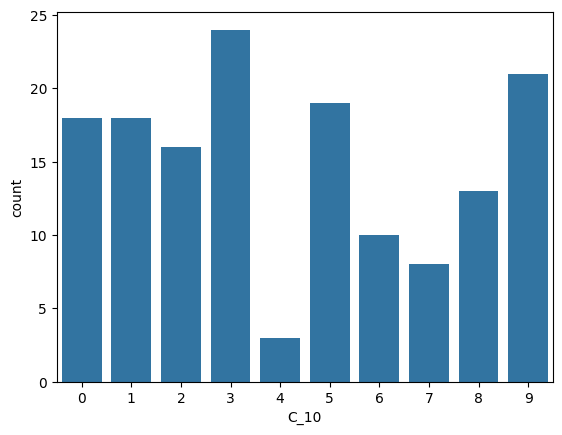

In [29]:
sns.countplot(x = iris_change['C_10'])

# finding the best value of number of clusters by elbow method based on WCSS (Within Cluster Sum of Squares)

In [38]:
# finding the best no of cluster
wss_iris=[]

for i in range(1,15):
    k_iris_c = KMeans(n_clusters=i)
    k_iris_c.fit(iris)
    pred_i =k_iris_c.labels_
    wss_iris.append(k_iris_c.inertia_)

([<matplotlib.axis.YTick at 0x23b3d4754b0>,
 [Text(0, 727.8817333333334, '727.9'),
  Text(0, 184.94767676767677, '184.9'),
  Text(0, 109.76884142614601, '109.8'),
  Text(0, 77.24339389615274, '77.2'),
  Text(0, 72.02763119394267, '72.0'),
  Text(0, 49.34669467721182, '49.3'),
  Text(0, 39.64419552669554, '39.6'),
  Text(0, 35.01226609260306, '35.0'),
  Text(0, 35.223191897971304, '35.2'),
  Text(0, 29.58680468829416, '29.6'),
  Text(0, 27.829182759269713, '27.8'),
  Text(0, 27.004209387104126, '27.0'),
  Text(0, 23.891510239760237, '23.9'),
  Text(0, 23.187651106934005, '23.2')])

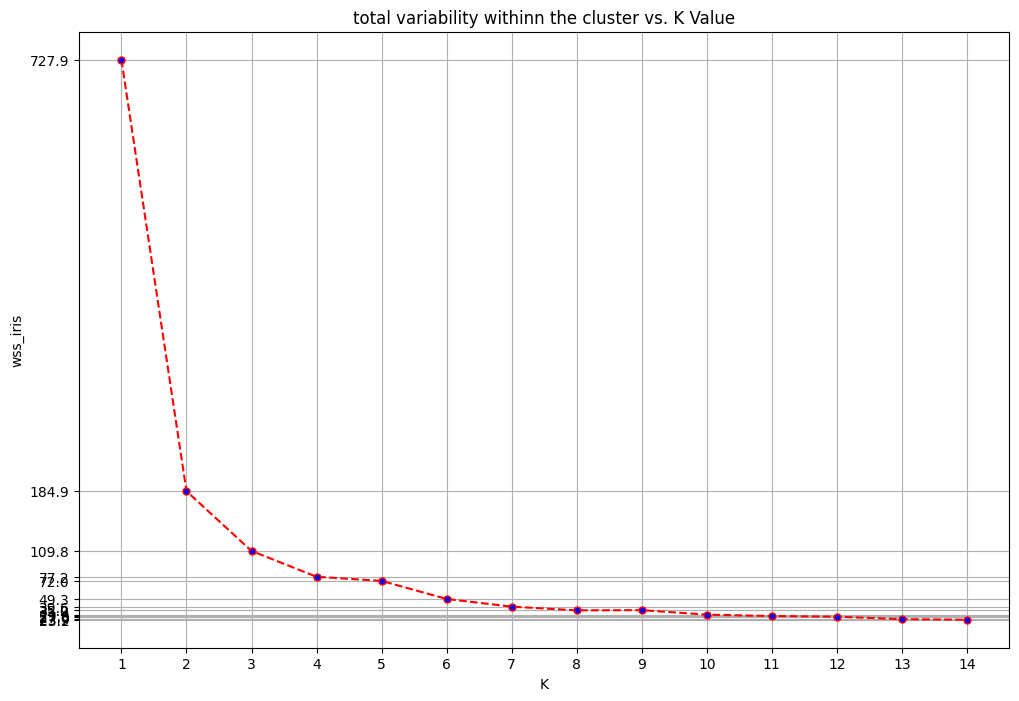

In [40]:
plt.figure(figsize=(12,8))
plt.plot(range(1,15),wss_iris,color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=5)
plt.title('total variability withinn the cluster vs. K Value')
plt.xlabel('K')
plt.xticks(range(1,15))
plt.grid()
plt.ylabel('wss_iris')
plt.yticks(wss_iris)

# Again using the KMeas for best number of Cluster

In [41]:
iris_best_n = KMeans(n_clusters=3)

In [42]:
iris_best_n.fit(iris)

KMeans(n_clusters=3)

In [43]:
iris_best_n.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 1, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1])

In [44]:
c_3 = pd.DataFrame(iris_best_n.labels_)
c_3 = c_3.rename(columns = {0:'C_3'})
c_3

,C_3
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,1
147,2
148,2


In [45]:
iris_change = pd.concat([iris_change, c_3],axis = 1)

iris_change

,sepal_length,sepal_width,petal_length,petal_width,C_10,C_3
0,5.1,3.5,1.4,0.2,9,0
1,4.9,3.0,1.4,0.2,1,0
2,4.7,3.2,1.3,0.2,1,0
3,4.6,3.1,1.5,0.2,1,0
4,5.0,3.6,1.4,0.2,9,0
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,2
146,6.3,2.5,5.0,1.9,7,1
147,6.5,3.0,5.2,2.0,2,2
148,6.2,3.4,5.4,2.3,2,2


In [46]:
iris_change['C_3'].value_counts()

C_3
1    62
0    50
2    38
Name: count, dtype: int64

In [47]:
iris_change['Actual_Species'] = data_iris['species']
iris_change.head(60)

,sepal_length,sepal_width,petal_length,petal_width,C_10,C_3,Actual_Species
0,5.1,3.5,1.4,0.2,9,0,Iris-setosa
1,4.9,3.0,1.4,0.2,1,0,Iris-setosa
2,4.7,3.2,1.3,0.2,1,0,Iris-setosa
3,4.6,3.1,1.5,0.2,1,0,Iris-setosa
4,5.0,3.6,1.4,0.2,9,0,Iris-setosa
5,5.4,3.9,1.7,0.4,9,0,Iris-setosa
6,4.6,3.4,1.4,0.3,1,0,Iris-setosa
7,5.0,3.4,1.5,0.2,9,0,Iris-setosa
8,4.4,2.9,1.4,0.2,1,0,Iris-setosa
9,4.9,3.1,1.5,0.1,1,0,Iris-setosa


<Axes: xlabel='C_3', ylabel='count'>

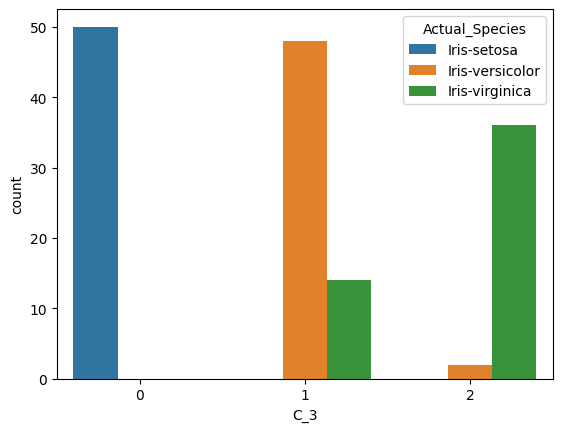

In [48]:
sns.countplot(x = iris_change['C_3'], hue = iris_change['Actual_Species'])